In [1]:
# -*- coding: utf-8 -*-
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or
# implied.
# See the License for the specific language governing permissions and
# limitations under the License.
#

# Pandas = Panel Data
Pandas documentation: https://pandas.pydata.org/pandas-docs/version/0.17.0/10min.html

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Series

In [3]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])
s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

### DataFrame

In [4]:
dates = pd.date_range('20130101', periods=6)
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [5]:
df = pd.DataFrame(np.random.randn(6,4), index=dates, columns=list('ABCD'))
df

,A,B,C,D
2013-01-01,-0.556222,0.540752,-0.367872,0.021724
2013-01-02,0.760786,0.194011,1.008892,-0.202026
2013-01-03,1.152305,0.886176,-0.816710,1.273246
2013-01-04,-0.237870,-0.223024,0.142101,0.643290
2013-01-05,-0.435215,-1.558638,-0.214902,-0.024703
2013-01-06,-1.834276,-1.854145,2.140940,0.463064


### Creating a DataFrame by passing a dict of objects

In [6]:
df2 = pd.DataFrame({ 'A' : 1.,
                     'B' : pd.Timestamp('20130102'),
                     'C' : pd.Series(1,index=list(range(4)),dtype='float32'),
                     'D' : np.array([3] * 4,dtype='int32'),
                     'E' : pd.Categorical(["test","train","test","train"]),
                     'F' : 'foo' })
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


# Viewing data

In [7]:
df2.dtypes

A          float64
B    datetime64[s]
C          float32
D            int32
E         category
F           object
dtype: object

In [8]:
df.head()

,A,B,C,D
2013-01-01,-0.556222,0.540752,-0.367872,0.021724
2013-01-02,0.760786,0.194011,1.008892,-0.202026
2013-01-03,1.152305,0.886176,-0.816710,1.273246
2013-01-04,-0.237870,-0.223024,0.142101,0.643290
2013-01-05,-0.435215,-1.558638,-0.214902,-0.024703


In [9]:
df.tail(2)

,A,B,C,D
2013-01-05,-0.435215,-1.558638,-0.214902,-0.024703
2013-01-06,-1.834276,-1.854145,2.140940,0.463064


In [10]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,-0.191749,-0.335811,0.315408,0.362432
std,1.058862,1.127448,1.083818,0.548299
min,-1.834276,-1.854145,-0.816710,-0.202026
25%,-0.525971,-1.224735,-0.329629,-0.013097
50%,-0.336543,-0.014506,-0.036401,0.242394
75%,0.511122,0.454067,0.792194,0.598233
max,1.152305,0.886176,2.140940,1.273246


In [11]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

# Transposing data

In [12]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,-0.556222,0.760786,1.152305,-0.237870,-0.435215,-1.834276
B,0.540752,0.194011,0.886176,-0.223024,-1.558638,-1.854145
C,-0.367872,1.008892,-0.816710,0.142101,-0.214902,2.140940
D,0.021724,-0.202026,1.273246,0.643290,-0.024703,0.463064


# Data selection

**One column = Series**

In [13]:
print(type(df['A']))
df['A']

<class 'pandas.core.series.Series'>


2013-01-01   -0.556222
2013-01-02    0.760786
2013-01-03    1.152305
2013-01-04   -0.237870
2013-01-05   -0.435215
2013-01-06   -1.834276
Freq: D, Name: A, dtype: float64

**Slicing**

In [14]:
df[0:3]

,A,B,C,D
2013-01-01,-0.556222,0.540752,-0.367872,0.021724
2013-01-02,0.760786,0.194011,1.008892,-0.202026
2013-01-03,1.152305,0.886176,-0.816710,1.273246


**Selection by label**

In [15]:
df.loc[dates[0]]

A   -0.556222
B    0.540752
C   -0.367872
D    0.021724
Name: 2013-01-01 00:00:00, dtype: float64

In [16]:
df.loc[:,['A','B']]

,A,B
2013-01-01,-0.556222,0.540752
2013-01-02,0.760786,0.194011
2013-01-03,1.152305,0.886176
2013-01-04,-0.237870,-0.223024
2013-01-05,-0.435215,-1.558638
2013-01-06,-1.834276,-1.854145


**Selection by Position**

In [17]:
df.iloc[1,1]

np.float64(0.19401138168225976)

In [18]:
df.iloc[3:5,0:2]

,A,B
2013-01-04,-0.237870,-0.223024
2013-01-05,-0.435215,-1.558638


**Boolean Indexing**

In [19]:
df[df.A > 0]

,A,B,C,D
2013-01-02,0.760786,0.194011,1.008892,-0.202026
2013-01-03,1.152305,0.886176,-0.816710,1.273246


In [20]:
df[df > 0]

,A,B,C,D
2013-01-01,NaN,0.540752,NaN,0.021724
2013-01-02,0.760786,0.194011,1.008892,NaN
2013-01-03,1.152305,0.886176,NaN,1.273246
2013-01-04,NaN,NaN,0.142101,0.643290
2013-01-05,NaN,NaN,NaN,NaN
2013-01-06,NaN,NaN,2.140940,0.463064


**Setting values ​​by label**

In [21]:
df.at[dates[0],'A'] = 0
df

,A,B,C,D
2013-01-01,0.000000,0.540752,-0.367872,0.021724
2013-01-02,0.760786,0.194011,1.008892,-0.202026
2013-01-03,1.152305,0.886176,-0.816710,1.273246
2013-01-04,-0.237870,-0.223024,0.142101,0.643290
2013-01-05,-0.435215,-1.558638,-0.214902,-0.024703
2013-01-06,-1.834276,-1.854145,2.140940,0.463064


# Missing Data

In [22]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ['E'])
df1

,A,B,C,D,E
2013-01-01,0.000000,0.540752,-0.367872,0.021724,NaN
2013-01-02,0.760786,0.194011,1.008892,-0.202026,NaN
2013-01-03,1.152305,0.886176,-0.816710,1.273246,NaN
2013-01-04,-0.237870,-0.223024,0.142101,0.643290,NaN


In [23]:
df1.loc[dates[0]:dates[1],'E'] = 1
df1

,A,B,C,D,E
2013-01-01,0.000000,0.540752,-0.367872,0.021724,1.0
2013-01-02,0.760786,0.194011,1.008892,-0.202026,1.0
2013-01-03,1.152305,0.886176,-0.816710,1.273246,NaN
2013-01-04,-0.237870,-0.223024,0.142101,0.643290,NaN


In [24]:
df1.dropna(how='any')

,A,B,C,D,E
2013-01-01,0.000000,0.540752,-0.367872,0.021724,1.0
2013-01-02,0.760786,0.194011,1.008892,-0.202026,1.0


In [25]:
df1.fillna(value=5)

,A,B,C,D,E
2013-01-01,0.000000,0.540752,-0.367872,0.021724,1.0
2013-01-02,0.760786,0.194011,1.008892,-0.202026,1.0
2013-01-03,1.152305,0.886176,-0.816710,1.273246,5.0
2013-01-04,-0.237870,-0.223024,0.142101,0.643290,5.0


**Boolean mask where values ​​are NaN**

In [26]:
pd.isnull(df1)

,A,B,C,D,E
2013-01-01,False,False,False,False,False
2013-01-02,False,False,False,False,False
2013-01-03,False,False,False,False,True
2013-01-04,False,False,False,False,True


# Operations

In [27]:
df.mean()

A   -0.099045
B   -0.335811
C    0.315408
D    0.362432
dtype: float64

In [28]:
df.mean(axis=0)
# df.mean(axis=1)

A   -0.099045
B   -0.335811
C    0.315408
D    0.362432
dtype: float64

### Applying functions to the data

In [29]:
df.apply(np.cumsum)

,A,B,C,D
2013-01-01,0.000000,0.540752,-0.367872,0.021724
2013-01-02,0.760786,0.734764,0.641020,-0.180302
2013-01-03,1.913092,1.620939,-0.175690,1.092944
2013-01-04,1.675222,1.397915,-0.033590,1.736235
2013-01-05,1.240007,-0.160723,-0.248491,1.711531
2013-01-06,-0.594269,-2.014867,1.892448,2.174595


In [30]:
df.apply(lambda x: x.max() - x.min())

A    2.986581
B    2.740320
C    2.957650
D    1.475272
dtype: float64

# Merging data

## Concat

In [31]:
df = pd.DataFrame(np.random.randn(10, 4))
df

,0,1,2,3
0,-2.092385,-1.089230,0.316701,-0.944036
1,0.344671,1.416237,-0.249513,0.504187
2,-1.197088,-0.103016,1.371981,-0.914075
3,0.029862,-0.896360,-0.003588,0.605891
4,0.438819,0.577518,-0.941264,-1.766048
5,-1.403277,-0.288907,-1.167927,-0.684629
6,0.092422,0.824153,-0.381342,-0.376365
7,0.019153,-0.374734,0.933370,1.841235
8,0.240132,1.026522,2.028685,-0.135208
9,-2.156358,-0.791468,0.179716,0.159923


In [32]:
pieces = [df[:3], df[3:7], df[7:]]
pieces

[          0         1         2         3
 0 -2.092385 -1.089230  0.316701 -0.944036
 1  0.344671  1.416237 -0.249513  0.504187
 2 -1.197088 -0.103016  1.371981 -0.914075,
           0         1         2         3
 3  0.029862 -0.896360 -0.003588  0.605891
 4  0.438819  0.577518 -0.941264 -1.766048
 5 -1.403277 -0.288907 -1.167927 -0.684629
 6  0.092422  0.824153 -0.381342 -0.376365,
           0         1         2         3
 7  0.019153 -0.374734  0.933370  1.841235
 8  0.240132  1.026522  2.028685 -0.135208
 9 -2.156358 -0.791468  0.179716  0.159923]

In [33]:
len(pieces)

3

In [34]:
pieces[1]

,0,1,2,3
3,0.029862,-0.896360,-0.003588,0.605891
4,0.438819,0.577518,-0.941264,-1.766048
5,-1.403277,-0.288907,-1.167927,-0.684629
6,0.092422,0.824153,-0.381342,-0.376365


In [35]:
pd.concat(pieces)


,0,1,2,3
0,-2.092385,-1.089230,0.316701,-0.944036
1,0.344671,1.416237,-0.249513,0.504187
2,-1.197088,-0.103016,1.371981,-0.914075
3,0.029862,-0.896360,-0.003588,0.605891
4,0.438819,0.577518,-0.941264,-1.766048
5,-1.403277,-0.288907,-1.167927,-0.684629
6,0.092422,0.824153,-0.381342,-0.376365
7,0.019153,-0.374734,0.933370,1.841235
8,0.240132,1.026522,2.028685,-0.135208
9,-2.156358,-0.791468,0.179716,0.159923


## Join

In [36]:
left = pd.DataFrame({'key': ['k1', 'k2'], 'lval': [1, 2]})
left

,key,lval
0,k1,1
1,k2,2


In [37]:
right = pd.DataFrame({'key': ['k1', 'k2'], 'rval': [3, 4]})
right

,key,rval
0,k1,3
1,k2,4


In [38]:
pd.merge(left, right, on='key')

,key,lval,rval
0,k1,1,3
1,k2,2,4


## Grouping

In [39]:
df = pd.DataFrame({'A' : ['foo', 'bar', 'foo', 'bar',
                          'foo', 'bar', 'foo', 'foo'],
                   'B' : ['one', 'one', 'two', 'three',
                          'two', 'two', 'one', 'three'],
                   'C' : np.random.randn(8),
                   'D' : np.random.randn(8)})
df

,A,B,C,D
0,foo,one,0.271134,1.248531
1,bar,one,-0.243991,-0.631309
2,foo,two,0.923126,0.370268
3,bar,three,0.534315,0.413393
4,foo,two,1.780523,-1.415338
5,bar,two,0.670442,1.226213
6,foo,one,-1.100774,-0.653296
7,foo,three,0.269813,-0.551641


In [40]:
df.groupby('A').sum()

,B,C,D
A,,,
bar,onethreetwo,0.960766,1.008298
foo,onetwotwoonethree,2.143821,-1.001477


In [41]:
df.groupby(['A','B']).sum()

C         D
A   B                        
bar one   -0.243991 -0.631309
    three  0.534315  0.413393
    two    0.670442  1.226213
foo one   -0.829640  0.595234
    three  0.269813 -0.551641
    two    2.703649 -1.045070

## Reshaping

### Stack

In [42]:
tuples = list(zip(*[['bar', 'bar', 'baz', 'baz',
                     'foo', 'foo', 'qux', 'qux'],
                    ['one', 'two', 'one', 'two',
                     'one', 'two', 'one', 'two']]))
tuples

[('bar', 'one'),
 ('bar', 'two'),
 ('baz', 'one'),
 ('baz', 'two'),
 ('foo', 'one'),
 ('foo', 'two'),
 ('qux', 'one'),
 ('qux', 'two')]

In [43]:
index = pd.MultiIndex.from_tuples(tuples, names=['first', 'second'])
index

MultiIndex([('bar', 'one'),
            ('bar', 'two'),
            ('baz', 'one'),
            ('baz', 'two'),
            ('foo', 'one'),
            ('foo', 'two'),
            ('qux', 'one'),
            ('qux', 'two')],
           names=['first', 'second'])

In [44]:
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=['A', 'B'])
df

A         B
first second                    
bar   one    -0.203941 -0.434008
      two     1.311756  0.794734
baz   one     0.802557  1.376965
      two     0.738782 -1.006742
foo   one     0.344679 -1.121876
      two    -1.134728 -0.878310
qux   one    -0.571521  1.116945
      two     1.829004 -0.437985

In [45]:
df2 = df[:4]
df2

A         B
first second                    
bar   one    -0.203941 -0.434008
      two     1.311756  0.794734
baz   one     0.802557  1.376965
      two     0.738782 -1.006742

In [46]:
stacked = df2.stack()
stacked

first  second   
bar    one     A   -0.203941
               B   -0.434008
       two     A    1.311756
               B    0.794734
baz    one     A    0.802557
               B    1.376965
       two     A    0.738782
               B   -1.006742
dtype: float64

In [47]:
stacked.shape

(8,)

**With a “stacked” DataFrame or Series (having a MultiIndex as the index), the inverse operation of stack() is unstack(), which by default unstacks the last level:**

In [48]:
stacked.unstack()

A         B
first second                    
bar   one    -0.203941 -0.434008
      two     1.311756  0.794734
baz   one     0.802557  1.376965
      two     0.738782 -1.006742

### Pivot Tables

In [49]:
df = pd.DataFrame({'A' : ['one', 'one', 'two', 'three'] * 3,
                   'B' : ['A', 'B', 'C'] * 4,
                   'C' : ['foo', 'foo', 'foo', 'bar', 'bar', 'bar'] * 2,
                   'D' : np.random.randn(12),
                   'E' : np.random.randn(12)})
df

,A,B,C,D,E
0,one,A,foo,-0.563283,-0.619160
1,one,B,foo,-1.051941,-0.367332
2,two,C,foo,-0.771455,-0.581062
3,three,A,bar,0.359230,0.329215
4,one,B,bar,-0.656776,1.338281
5,one,C,bar,-1.292863,-0.709847
6,two,A,foo,-1.010384,0.349900
7,three,B,foo,0.960301,-0.362276
8,one,C,foo,2.549018,-0.283612
9,one,A,bar,0.922208,-0.473640


In [50]:
pd.pivot_table(df, values='D', index=['A', 'B'], columns=['C'])

C             bar       foo
A     B                    
one   A  0.922208 -0.563283
      B -0.656776 -1.051941
      C -1.292863  2.549018
three A  0.359230       NaN
      B       NaN  0.960301
      C -1.174361       NaN
two   A       NaN -1.010384
      B  0.374722       NaN
      C       NaN -0.771455

# Time Series

In [51]:
rng = pd.date_range('1/1/2012', periods=100, freq='S')
rng

C:\Users\Andrii\AppData\Local\Temp\ipykernel_24712\2150156700.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  rng = pd.date_range('1/1/2012', periods=100, freq='S')


DatetimeIndex(['2012-01-01 00:00:00', '2012-01-01 00:00:01',
               '2012-01-01 00:00:02', '2012-01-01 00:00:03',
               '2012-01-01 00:00:04', '2012-01-01 00:00:05',
               '2012-01-01 00:00:06', '2012-01-01 00:00:07',
               '2012-01-01 00:00:08', '2012-01-01 00:00:09',
               '2012-01-01 00:00:10', '2012-01-01 00:00:11',
               '2012-01-01 00:00:12', '2012-01-01 00:00:13',
               '2012-01-01 00:00:14', '2012-01-01 00:00:15',
               '2012-01-01 00:00:16', '2012-01-01 00:00:17',
               '2012-01-01 00:00:18', '2012-01-01 00:00:19',
               '2012-01-01 00:00:20', '2012-01-01 00:00:21',
               '2012-01-01 00:00:22', '2012-01-01 00:00:23',
               '2012-01-01 00:00:24', '2012-01-01 00:00:25',
               '2012-01-01 00:00:26', '2012-01-01 00:00:27',
               '2012-01-01 00:00:28', '2012-01-01 00:00:29',
               '2012-01-01 00:00:30', '2012-01-01 00:00:31',
               '2012-01-

In [52]:
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
ts

2012-01-01 00:00:00    385
2012-01-01 00:00:01    321
2012-01-01 00:00:02    411
2012-01-01 00:00:03    340
2012-01-01 00:00:04     87
                      ... 
2012-01-01 00:01:35    248
2012-01-01 00:01:36    182
2012-01-01 00:01:37    406
2012-01-01 00:01:38    222
2012-01-01 00:01:39     94
Freq: s, Length: 100, dtype: int32

In [53]:
ts.resample('5Min').sum()

2012-01-01    23204
Freq: 5min, dtype: int32

In [54]:
rng = pd.date_range('3/6/2012 00:00', periods=5, freq='D')
rng

DatetimeIndex(['2012-03-06', '2012-03-07', '2012-03-08', '2012-03-09',
               '2012-03-10'],
              dtype='datetime64[ns]', freq='D')

In [55]:
ts = pd.Series(np.random.randn(len(rng)), rng)
ts

2012-03-06   -1.036799
2012-03-07   -0.319680
2012-03-08   -0.257813
2012-03-09    1.562134
2012-03-10   -1.207090
Freq: D, dtype: float64

In [56]:
ts_utc = ts.tz_localize('UTC')
ts_utc

2012-03-06 00:00:00+00:00   -1.036799
2012-03-07 00:00:00+00:00   -0.319680
2012-03-08 00:00:00+00:00   -0.257813
2012-03-09 00:00:00+00:00    1.562134
2012-03-10 00:00:00+00:00   -1.207090
Freq: D, dtype: float64

# Categoricals

In [57]:
df = pd.DataFrame({"id":[1,2,3,4,5,6], "raw_grade":['a', 'b', 'b', 'a', 'a', 'e']})
df

,id,raw_grade
0,1,a
1,2,b
2,3,b
3,4,a
4,5,a
5,6,e


In [58]:
df["grade"] = df["raw_grade"].astype("category")
df["grade"]

0    a
1    b
2    b
3    a
4    a
5    e
Name: grade, dtype: category
Categories (3, object): ['a', 'b', 'e']

In [59]:
df["verbal_grade"] = df["grade"].cat.rename_categories(["bad", "good", "very good"])
df["verbal_grade"]

0          bad
1         good
2         good
3          bad
4          bad
5    very good
Name: verbal_grade, dtype: category
Categories (3, object): ['bad', 'good', 'very good']

In [60]:
df.sort_values(by="grade")

,id,raw_grade,grade,verbal_grade
0,1,a,a,bad
3,4,a,a,bad
4,5,a,a,bad
1,2,b,b,good
2,3,b,b,good
5,6,e,e,very good


In [61]:
df.groupby("grade").size()

C:\Users\Andrii\AppData\Local\Temp\ipykernel_24712\3951628473.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("grade").size()


grade
a    3
b    2
e    1
dtype: int64

# Plotting

In [62]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2000', periods=1000))
ts

2000-01-01   -0.015356
2000-01-02    0.617458
2000-01-03    0.727613
2000-01-04   -1.917052
2000-01-05    0.528381
                ...   
2002-09-22   -0.512381
2002-09-23   -0.813595
2002-09-24   -0.285448
2002-09-25    1.305470
2002-09-26    0.866334
Freq: D, Length: 1000, dtype: float64

In [63]:
ts = ts.cumsum()
ts

2000-01-01    -0.015356
2000-01-02     0.602102
2000-01-03     1.329715
2000-01-04    -0.587338
2000-01-05    -0.058956
                ...    
2002-09-22   -45.816903
2002-09-23   -46.630497
2002-09-24   -46.915945
2002-09-25   -45.610475
2002-09-26   -44.744141
Freq: D, Length: 1000, dtype: float64

<Axes: >

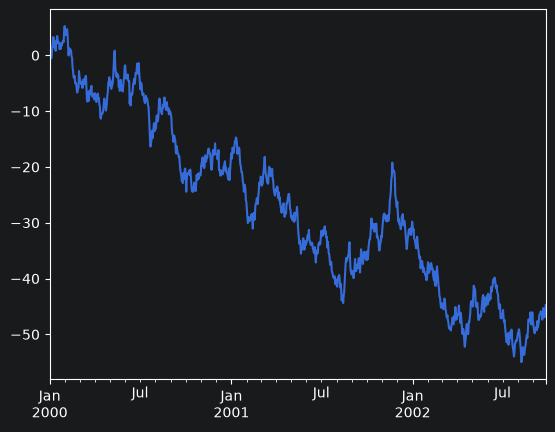

In [64]:
ts.plot()

In [65]:
df = pd.DataFrame(np.random.randn(1000, 4), index=ts.index,
                  columns=['A', 'B', 'C', 'D'])
df

,A,B,C,D
2000-01-01,-0.879185,-1.472359,1.262596,-0.018586
2000-01-02,-1.283161,0.366886,-0.971071,-0.398048
2000-01-03,0.524017,-0.984224,0.451346,0.363633
2000-01-04,0.023858,-1.693394,0.918737,-0.404009
2000-01-05,-0.830796,-1.035990,1.732261,-0.216754
...,...,...,...,...
2002-09-22,1.600054,-0.932029,-0.093577,0.968828
2002-09-23,1.220730,-0.446673,0.811922,0.853080
2002-09-24,0.734678,1.136959,0.859472,-0.859679
2002-09-25,1.084289,1.250597,-1.287817,0.873996


In [66]:
df = df.cumsum()
df

,A,B,C,D
2000-01-01,-0.879185,-1.472359,1.262596,-0.018586
2000-01-02,-2.162346,-1.105473,0.291525,-0.416634
2000-01-03,-1.638330,-2.089696,0.742871,-0.053001
2000-01-04,-1.614472,-3.783090,1.661608,-0.457010
2000-01-05,-2.445267,-4.819080,3.393869,-0.673765
...,...,...,...,...
2002-09-22,-4.396809,-43.092170,27.179768,-3.350323
2002-09-23,-3.176079,-43.538843,27.991690,-2.497243
2002-09-24,-2.441401,-42.401884,28.851162,-3.356921
2002-09-25,-1.357112,-41.151287,27.563345,-2.482926


<Figure size 640x480 with 0 Axes>

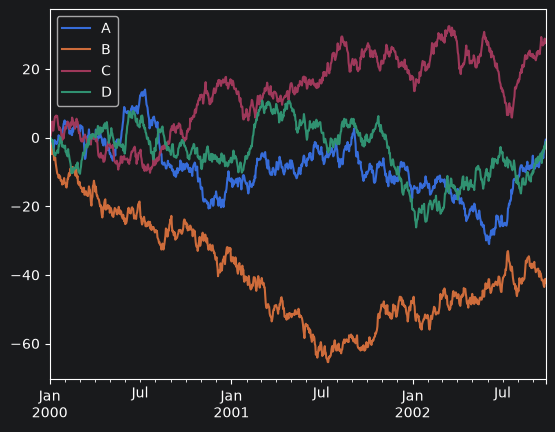

In [67]:
plt.figure() 
df.plot() 
plt.legend(loc='best')

# 100-pandas-puzzles

**https://github.com/FIIT-IAU/100-pandas-puzzles** (forked from https://github.com/ajcr/100-pandas-puzzles)